# 🏠 Tehran House Price Prediction

A machine learning project that predicts house prices in Tehran using CatBoost, XGBoost, and Random Forest.

This notebook is the analytical/educational version of the project: it includes exploratory data analysis (EDA), visual analysis of features, model comparison, and result analysis with charts.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("tehranHprice.csv")
df.head()


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3473 entries, 0 to 3472
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3473 non-null   int64  
 1   Room        3473 non-null   int64  
 2   Parking     3473 non-null   bool   
 3   Warehouse   3473 non-null   bool   
 4   Elevator    3473 non-null   bool   
 5   Address     3450 non-null   object 
 6   Price       3473 non-null   float64
 7   Price(USD)  3473 non-null   float64
dtypes: bool(3), float64(2), int64(2), object(1)
memory usage: 146.0+ KB


In [4]:
df.isnull().sum()


Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

**23 missing values** exist in the `Address` column. These rows are dropped, since the neighborhood can't be reliably imputed.

In [5]:
print("Duplicated rows:", df.duplicated().sum())


Duplicated rows: 208


There are also **208 duplicate records** in the dataset.

## 3. Data Cleaning

In [6]:
df.dropna(inplace=True)
df = df.drop_duplicates()
df = df[df["Price"] > 0]

print("Final shape:", df.shape)


Final shape: (3242, 8)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Price Distribution

We compare the price distribution before and after the log transform to see why `log1p` is used.

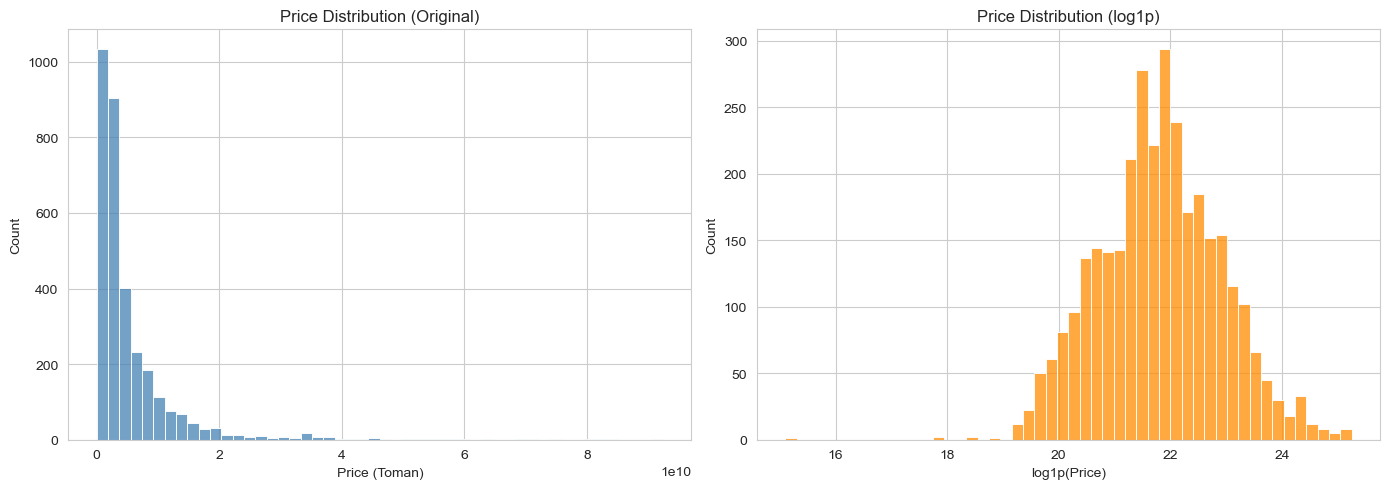

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution (Original)")
axes[0].set_xlabel("Price (Toman)")

sns.histplot(np.log1p(df["Price"]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Price Distribution (log1p)")
axes[1].set_xlabel("log1p(Price)")

plt.tight_layout()
plt.show()


📌 As shown, the original price distribution is strongly **right-skewed** (few very expensive houses, most cheaper). The `log1p` transform reduces this skew and makes the distribution closer to normal, which helps most regression models.

### 4.2 Area vs Price

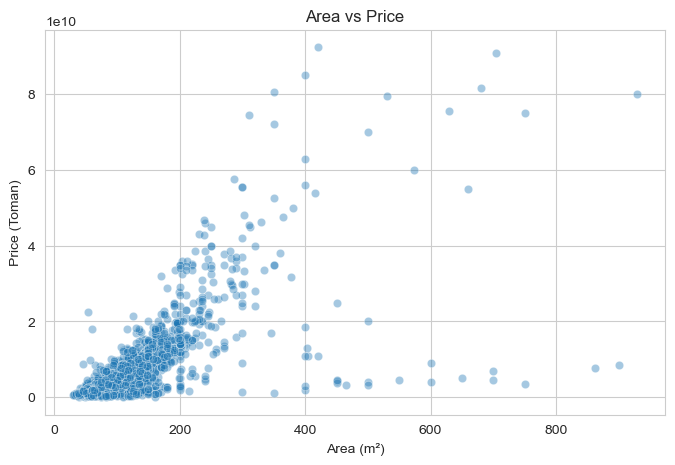

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Area", y="Price", alpha=0.4)
plt.title("Area vs Price")
plt.xlabel("Area (m²)")
plt.ylabel("Price (Toman)")
plt.show()


📌 An overall positive relationship between area and price is visible, but there are a few outliers with very large area or unusual price.

### 4.3 Room Count Distribution

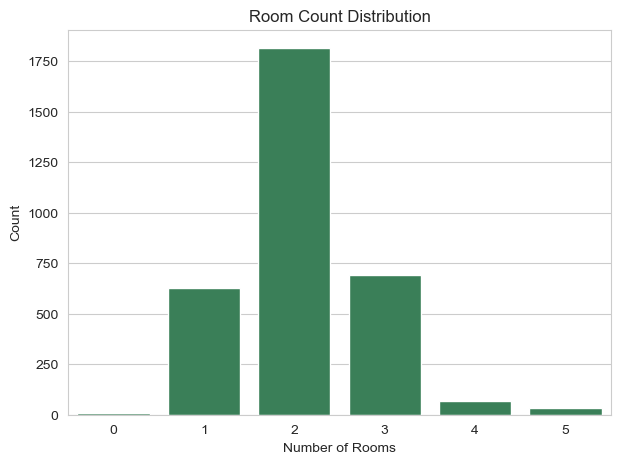

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Room", color="seagreen")
plt.title("Room Count Distribution")
plt.xlabel("Number of Rooms")
plt.ylabel("Count")
plt.show()


### 4.4 Effect of Amenities (Parking / Warehouse / Elevator) on Price

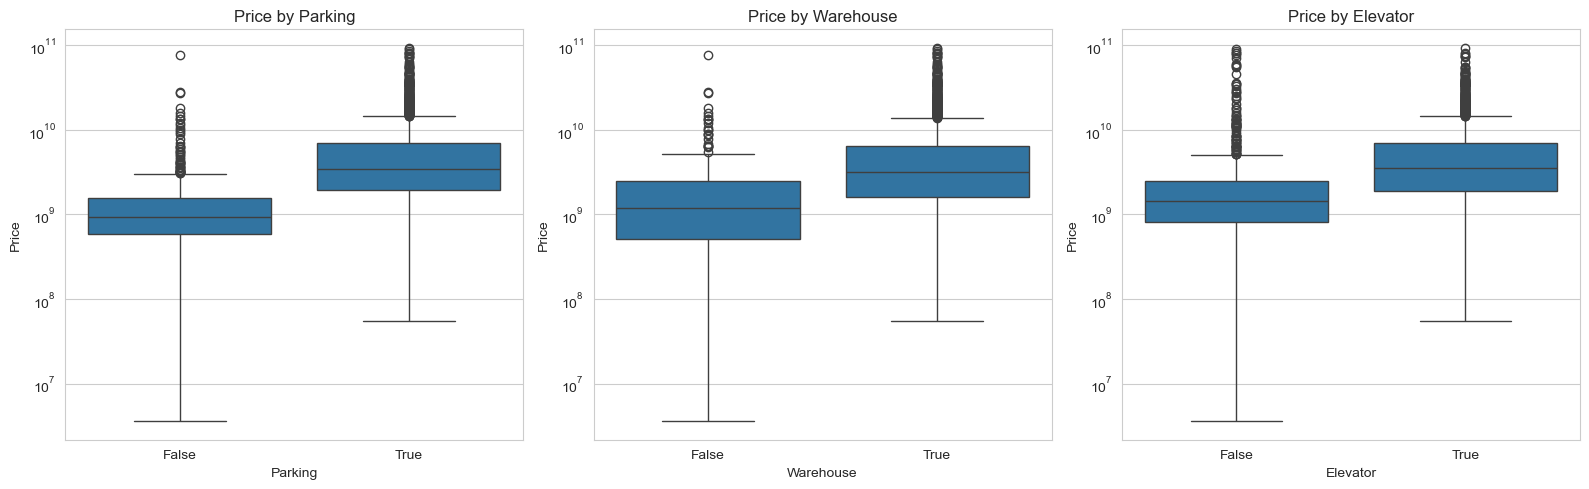

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, col in zip(axes, ["Parking", "Warehouse", "Elevator"]):
    sns.boxplot(data=df, x=col, y="Price", ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


📌 For all three features, houses with the amenity (value 1) have a higher median price than those without; parking and elevator show a more noticeable effect.

### 4.5 Top 15 Most Expensive Neighborhoods (by Average Price)

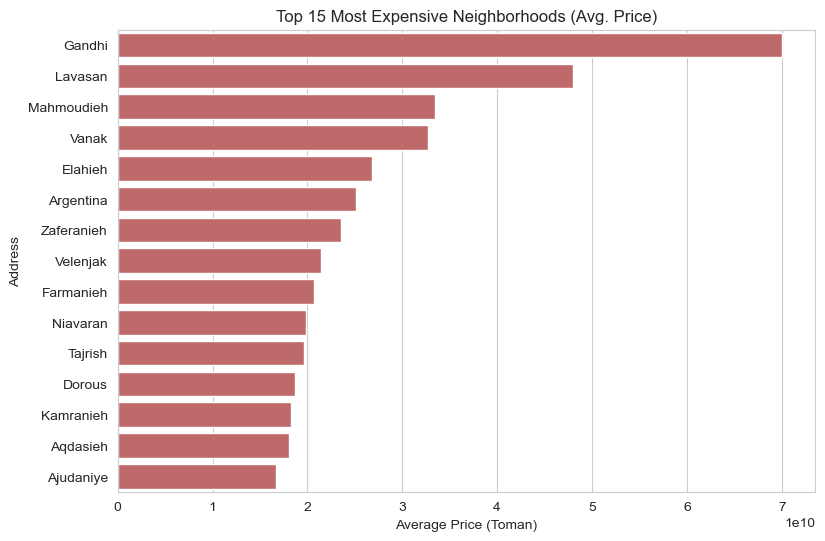

In [11]:
top_addresses = (
    df.groupby("Address")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9,6))
sns.barplot(x=top_addresses.values, y=top_addresses.index, color="indianred")
plt.title("Top 15 Most Expensive Neighborhoods (Avg. Price)")
plt.xlabel("Average Price (Toman)")
plt.ylabel("Address")
plt.show()


### 4.6 Correlation Matrix of Numeric Features

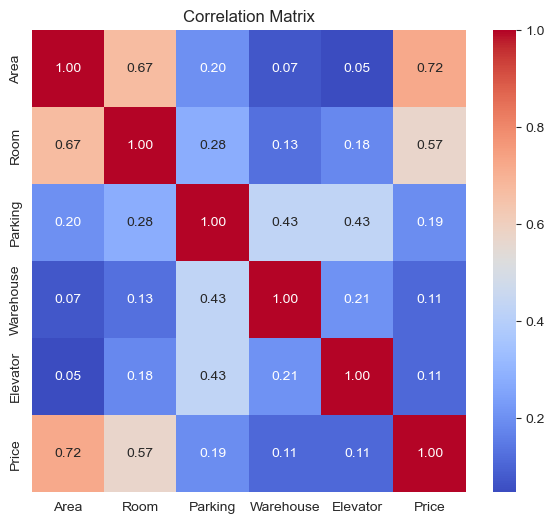

In [12]:
numeric_cols = ["Area", "Room", "Parking", "Warehouse", "Elevator", "Price"]

plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


📌 `Area` has the strongest linear correlation with `Price`. The binary features (Parking/Warehouse/Elevator) show weaker correlation, but as seen in the box plots, their effect is non-linear and meaningful in interaction with other features.

Using get_dummies because of the categorical (text) values

In [ ]:
dummy_address = pd.get_dummies(df["Address"])
df = df.merge(dummy_address , left_index=True , right_index=True )
df.drop(columns = 'Address' , inplace = True ) 
df = df.astype(int)

## 5. Train / Test Split

In [ ]:
cat_feature = ["Address"]
x = df.drop(columns=["Price", "Price(USD)"])
# print((df["Price"] / df["Price(USD)"]).describe())
# print(df[["Price", "Price(USD)"]].corr())
# ! Price(USD) is not used in y, since it has no notable effect on model learning
y = np.log1p(df["Price"])   # log-transformed target

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)

print("Train shape:", train_x.shape)
print("Test shape :", test_x.shape)


Train shape: (2593, 6)
Test shape : (649, 6)


📌 The reason I used log1p instead of IQR and similar methods was that applying IQR-based limits to features such as area would remove properties larger than 150 square meters from the dataset. This would have negatively affected the model’s learning process and reduced its predictive accuracy.

I also avoided applying such filtering to the price feature because the housing market in Tehran is highly skewed and sometimes irrational. Some properties have prices that do not follow typical market patterns, and using IQR would have resulted in the removal of many potentially useful data points.

Therefore, I chose to handle this issue using log1p transformation, particularly for prices measured in Iranian Tomans. This approach reduces the impact of extreme values while preserving valuable information in the dataset, allowing the model to learn from a broader range of observations.

## 6. Model Search Helper Function

A function that uses `GridSearchCV` to find the best hyperparameters and computes the model's score (**after converting the price back from log scale with `expm1`**).

In [14]:
def mp_finder(model, parameters):
    grid = GridSearchCV(
        model,
        param_grid=parameters,
        refit=True,
        cv=KFold(shuffle=True, random_state=1),
        n_jobs=-1,
    )
    grid_fit = grid.fit(train_x, train_y)

    trainx_pred = grid_fit.predict(train_x)
    y_pred = grid_fit.predict(test_x)

    train_score = r2_score(np.expm1(train_y), np.expm1(trainx_pred))
    test_score = r2_score(np.expm1(test_y), np.expm1(y_pred))
    rmse = np.sqrt(mean_squared_error(np.expm1(test_y), np.expm1(y_pred)))

    model_name = str(model).split("(")[0]
    print(f"Best params for {model_name}: {grid_fit.best_params_}")
    print("-" * 40)
    print(f"R² (train): {train_score:0.2%}")
    print(f"R² (test) : {test_score:0.2%}")
    print(f"RMSE      : {rmse:,.0f}")

    return train_score, test_score, rmse


## 7. Hyperparameter Search (Optional — Time Consuming)

Running the full `GridSearchCV` for all three models is time-consuming. The cells below are kept commented out so they can be re-run if needed. The results obtained (from a previous run) are shown below as a table and chart.

In [ ]:
# xg = XGBRegressor(n_jobs=-1)
# xg_param = {
#     "n_estimators": [100, 150, 200],
#     "max_depth": [3, 4, 5],
#     "learning_rate": [0.05, 0.1],
#     "subsample": [0.8, 1],
#     "colsample_bytree": [0.8, 1],
#     "min_child_weight": [1, 3],
# }
# xg_train_score, xg_test_score, xg_rmse = mp_finder(xg, xg_param)

# ?best parametr for XGBRegressor is {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8} 
# ?--------------------
# ?(r2score) in the training set is  84.56%  for XGBRegressor model
# ?(r2score) in the testing set is  67.94%  for XGBRegressor model
# ?--------------------
# ?RMSE is 318,478,591.0305224 for XGBRegressor model


In [ ]:
# cb = CatBoostRegressor(verbose=0)
# cb_param = {
#     "iterations": [300, 500],
#     "depth": [4, 6, 8],
#     "learning_rate": [0.03, 0.05, 0.1],
#     "l2_leaf_reg": [1, 3, 5],
#     "subsample": [0.8, 1],
#     "colsample_bylevel": [0.8, 1],
# }
# cb_train_score, cb_test_score, cb_rmse = mp_finder(cb, cb_param)

# ?best parametr for CatBoostRegressor is {'colsample_bylevel': 1, 'depth': 4, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'subsample': 1} 
# ?--------------------considering the effect introduced by the get_dummies endoding process---------------------------
# ?(r2score) in the training set is  86.23%  for CatBoostRegressor model
# ?(r2score) in the testing set is  68.71%  for CatBoostRegressor model
# ?--------------------
# ?RMSE is 314,591,703.22893304 for CatBoostRegressor model

In [ ]:
# rf = RandomForestRegressor(random_state=1, n_jobs=-1)
# rf_param = {
#     "n_estimators": [300, 500, 800],
#     "max_depth": [10, 15, 20, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2"],
# }
# rf_train_score, rf_test_score, rf_rmse = mp_finder(rf, rf_param)

# ?best parametr for RandomForestRegressor is {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800} 
# ?--------------------
# ?(r2score) in the training set is  93.52%  for RandomForestRegressor model
# ?(r2score) in the testing set is  69.30%  for RandomForestRegressor model
# ?--------------------
# ?RMSE is 311,630,290.5113327 for RandomForestRegressor model


## 8. Model Comparison

Results obtained from `GridSearchCV` for all three models (from a full run):

In [18]:
results = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost", "Random Forest"],
    "R2_Train": [0.8456, 0.8623, 0.9352],
    "R2_Test":  [0.6794, 0.6871, 0.6930],
    "RMSE_Test": [318_478_591, 314_591_703, 311_630_290],
})
results


,Model,R2_Train,R2_Test,RMSE_Test
0,XGBoost,0.8456,0.6794,318478591
1,CatBoost,0.8623,0.6871,314591703
2,Random Forest,0.9352,0.6930,311630290


**Note**! Because (get_dummies) was used to handle the categorical values, CatBoost's accuracy was **negatively affected**, since it can natively handle text values when fitting. But since we're not fitting the final model at this stage and just want to see its performance on the dataset, we use (get_dummies) here — and **before fitting the final model**, we **comment** out the (get_dummies) part for better accuracy.

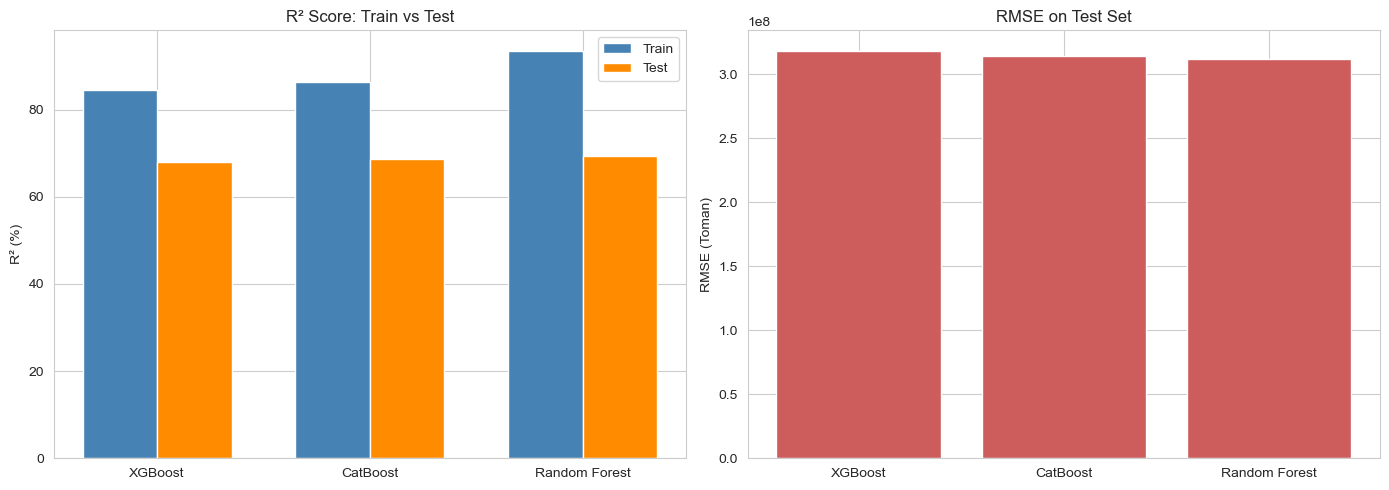

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

x_pos = np.arange(len(results))
width = 0.35

axes[0].bar(x_pos - width/2, results["R2_Train"]*100, width, label="Train", color="steelblue")
axes[0].bar(x_pos + width/2, results["R2_Test"]*100, width, label="Test", color="darkorange")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results["Model"])
axes[0].set_ylabel("R² (%)")
axes[0].set_title("R² Score: Train vs Test")
axes[0].legend()

axes[1].bar(results["Model"], results["RMSE_Test"], color="indianred")
axes[1].set_ylabel("RMSE (Toman)")
axes[1].set_title("RMSE on Test Set")

plt.tight_layout()
plt.show()


📌 All three models reach roughly the same test accuracy (~68%), but **Random Forest** has the largest gap between train and test R², indicating more overfitting than the other two. **CatBoost** has a better balance between accuracy and overfitting, which is why it was chosen as the final model, while also natively handling the categorical `Address` feature.

-**Note**! Before fitting the catboost model, **comment** out the **get_dummies** section

## 9. Train Final Model (CatBoost)

In [20]:
model_reg = CatBoostRegressor(
    iterations=500,
    depth=4,
    l2_leaf_reg=1,
    learning_rate=0.1,
    colsample_bylevel=1,
    subsample=1,
    cat_features=cat_feature,
    verbose=0,
)

model_reg.fit(train_x, train_y, eval_set=(test_x, test_y), early_stopping_rounds=50)


CatBoostRegressor(cat_features=['Address'], colsample_bylevel=1, depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1, loss_function='RMSE', subsample=1, verbose=0)

In [21]:
trainlog_pred = model_reg.predict(train_x)
model_pred = model_reg.predict(test_x)

train_r2 = r2_score(np.expm1(train_y), np.expm1(trainlog_pred))
test_r2 = r2_score(np.expm1(test_y), np.expm1(model_pred))
rmse = np.sqrt(mean_squared_error(np.expm1(test_y), np.expm1(model_pred)))

print(f"R² (train): {train_r2:0.2%}")
print(f"R² (test) : {test_r2:0.2%}")
print(f"RMSE      : {rmse:,.0f}")


R² (train): 78.08%
R² (test) : 72.13%
RMSE      : 4,195,572,690


### 9.1 Actual vs Predicted

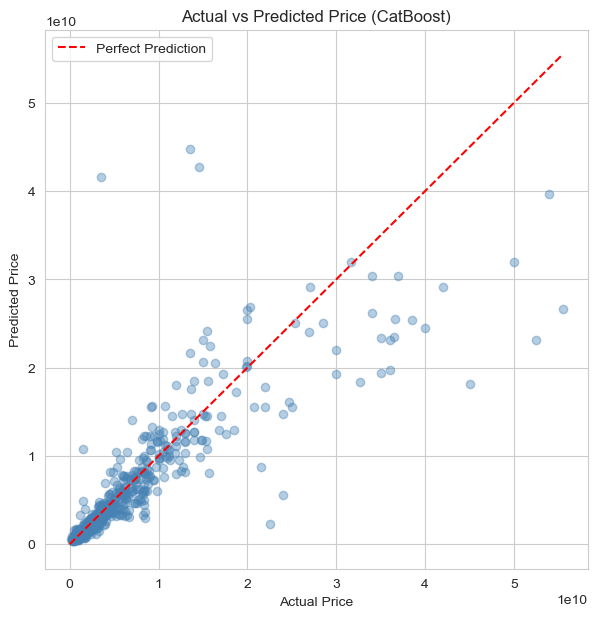

In [22]:
plt.figure(figsize=(7,7))
actual = np.expm1(test_y)
predicted = np.expm1(model_pred)

plt.scatter(actual, predicted, alpha=0.4, color="steelblue")
max_val = max(actual.max(), predicted.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (CatBoost)")
plt.legend()
plt.show()


📌 The closer the points are to the red line (perfect prediction), the more accurate the model. More scatter at higher prices shows the model has higher error for more expensive houses.

### 9.2 Feature Importance

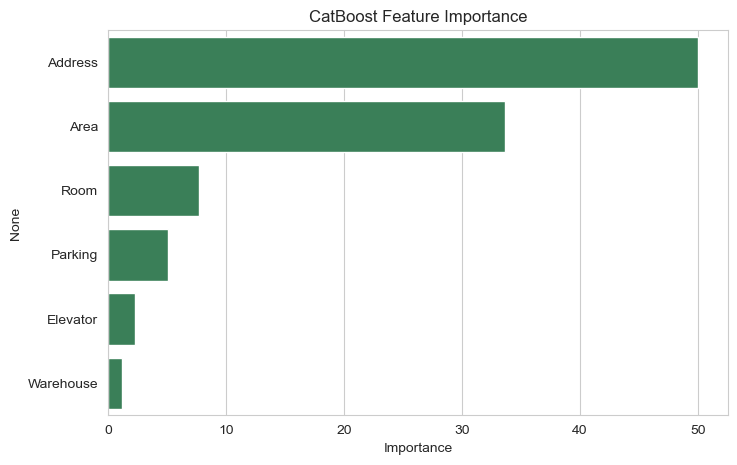

In [23]:
importances = pd.Series(
    model_reg.get_feature_importance(),
    index=train_x.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, color="seagreen")
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.show()


📌 As expected, `Area` and `Address` have the highest impact on price prediction.

## 10. Interactive Prediction (CLI)

This section takes details of a new house from the user and predicts its price. (It can be run in the notebook, but its interactive nature fits the `main.py` script better.)

In [ ]:
valid_addresses = df["Address"].unique()

while True:
    try:
        Area = int(input("area : "))
        Room = int(input("room : "))
        Parking = int(input("parking(0/1) :"))
        Warehouse = int(input("Warehouse(0/1) :"))
        Elevator = int(input("Elevator(0/1) : "))
        Address = input("Address : ").strip().title()
        usd_rate = float(input("Current USD rate: "))
        if Address not in valid_addresses:
            print("Address not found in dataset")
            continue
    except Exception:
        print("please enter valid values")
        continue

    newhouse = pd.DataFrame({
        "Area": [Area],
        "Room": [Room],
        "Parking": [Parking],
        "Warehouse": [Warehouse],
        "Elevator": [Elevator],
        "Address": [Address],
    })

    predict_nh = model_reg.predict(newhouse)
    predict_price = np.expm1(predict_nh[0])
    predict_usdprice = predict_price / usd_rate

    print(f"\nPredicted Price: {predict_price:,.0f} Toman\n")
    print(f"USD predicted price: {predict_usdprice:,.0f} USD\n")

    again = input("Continue? (y/n): ")
    if again.lower() != "y":
        print("thanks for your time")
        break


## 11. Summary

-R² (train): 78.08%
 R² (test) : 72.13%
 RMSE      : 4,195,572,690

- Most important features: `Area` and `Address`
- The `log1p` transform on price was necessary due to the strongly skewed distribution
- Used the GridSearchCV function to find the best model
- Used get_dummies to handle categorical values in the GridSearchCV step
- CatBoost was preferred over XGBoost and Random Forest due to its native handling of categorical features and better balance between accuracy/overfitting